In [1]:
import os
from os import listdir
import pandas as pd
import numpy as np
import glob
import cv2
import json
from os.path import expanduser

from tqdm import tqdm

import torch 
from torchvision import models
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn 
import torchvision.transforms as transforms
from torchsummary import summary

from sklearn.model_selection import train_test_split


import matplotlib.pyplot as plt 
from PIL import Image

In [2]:
home = expanduser("~")

parent_path =  home + "/Pictures/" + "Data/"

root_dir = parent_path + "merge_folder-2022-11-03-18-32"

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=True)

NameError: name 'train_dataset' is not defined

In [5]:
# Specify a path
PATH = parent_path + "entire_model_vgg19_50.pth"

In [6]:
# Load
model = torch.load(PATH)
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [7]:
print(img_arr.shape)

NameError: name 'img_arr' is not defined

In [8]:
import cv2

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                              std=[0.229, 0.224, 0.225])
# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/2D_proj_ds/61.rgb.jpg')

img = cv2.imread('/home/jc-merlab/frame0000.jpg')

# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/test_img.jpg')

print(img.shape)

img_arr = img/255.0
img_arr = cv2.resize(img_arr, (224,224)) 
img_arr = torch.tensor(img_arr).permute(2,0,1) 
print(type(img_arr))
img_arr = normalize(img_arr).float()
img_arr = img_arr.to(device)
# img = list(img)


(480, 640, 3)
<class 'torch.Tensor'>


In [9]:
franka_key_points = model(img_arr[None]).flatten().detach().cpu()

print(franka_key_points)

fkpx = franka_key_points[:6]*img.shape[1]

print(fkpx)

fkpy = franka_key_points[6:]*img.shape[0]

print(fkpy)

tensor([0.4170, 0.4125, 0.4178, 0.4490, 0.5556, 0.5867, 0.7686, 0.6016, 0.4572,
        0.4614, 0.4644, 0.4630])
tensor([266.8662, 263.9895, 267.4213, 287.3567, 355.5969, 375.4990])
tensor([368.9250, 288.7513, 219.4414, 221.4799, 222.9202, 222.2494])


640


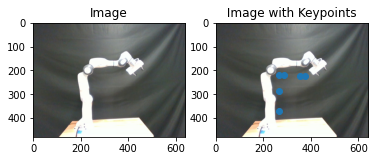

In [10]:
# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/2D_proj_ds/61.rgb.jpg')

# img = cv2.imread('/home/jc-merlab/Deep_Learning/merlab_dl_data/test_img.jpg')

img = cv2.imread('/home/jc-merlab/frame0000.jpg')
img = img[:,:,::-1] 
print(img.shape[1])
plt.subplot(121)
plt.title("Image")                                                        
plt.imshow(img)
plt.subplot(122)
plt.title(" Image with Keypoints ")
plt.imshow(img)
plt.scatter(franka_key_points[:6]*img.shape[1], franka_key_points[6:]*img.shape[0])   # scaling the keypoints with image dimension
plt.show()

In [13]:
import cv2
vidcap = cv2.VideoCapture(parent_path + 'nov_v1.avi')
success,image = vidcap.read()
count = 0
while success:
    img_arr = image/255.0
    img_arr = cv2.resize(img_arr, (224,224)) 
    img_arr = torch.tensor(img_arr).permute(2,0,1) 
    print(type(img_arr))
    img_arr = normalize(img_arr).float()
    img_arr = img_arr.to(device)
    franka_key_points = model(img_arr[None]).flatten().detach().cpu()
    fkpx = franka_key_points[:6]*img.shape[1]
    fkpy = franka_key_points[6:]*img.shape[0]
    
    cv_img = image
    cv_img = cv_img[:,:,::-1] 
    plt.subplot(121)
    plt.title("Image")                                                        
    plt.imshow(cv_img)
    plt.subplot(122)
    plt.title(" Image with Keypoints ")
    plt.imshow(cv_img)
    plt.scatter(franka_key_points[:6]*cv_img.shape[1], franka_key_points[6:]*cv_img.shape[0])   # scaling the keypoints with image dimension
    plt.show()
    
    
#     cv2.circle(cv_img,(int(fkpx[0]), int(fkpy[0])),5,(0, 0, 255),-1)
#     cv2.circle(cv_img,(int(fkpx[1]), int(fkpy[1])),10,(0, 255, 0),-1)
#     cv2.circle(cv_img,(int(fkpx[2]), int(fkpy[2])),5,(255, 0, 0),-1)
#     cv2.circle(cv_img,(int(fkpx[3]), int(fkpy[3])),10,(255, 255, 0),-1)
#     cv2.circle(cv_img,(int(fkpx[4]), int(fkpy[4])),5,(0, 255, 255),-1)
#     cv2.circle(cv_img,(int(fkpx[5]), int(fkpy[5])),10,(255, 0, 255),-1)
#     cv2.imwrite("image"+str(count)+".jpg", cv_img)
#     cv2.circle(cv_img,(int(fkpx[6]), int(fkpy[6])),5,(255, 153, 255),-1)   
        
    success,image = vidcap.read()
    
    count += 1

In [15]:
# Creaed by Abhay



import cv2
vidcap = cv2.VideoCapture(parent_path + 'nov_v1.avi')
success,image = vidcap.read()
count = 0
video_from_images = []

while success:
    
    image_2 = image
    img_arr = image_2/255.0
    img_arr = cv2.resize(img_arr, (224,224)) 
    img_arr = torch.tensor(img_arr).permute(2,0,1) 
#     print(type(img_arr))
    img_arr = normalize(img_arr).float()
    img_arr = img_arr.to(device)
    franka_key_points = model(img_arr[None]).flatten().detach().cpu()
    fkpx = franka_key_points[:6]*img.shape[1]
    fkpy = franka_key_points[6:]*img.shape[0]
    
    cv2.circle(image,(int(fkpx[0]), int(fkpy[0])),5,(0, 0, 255),-1)
    cv2.circle(image,(int(fkpx[1]), int(fkpy[1])),10,(0, 255, 0),-1)
    cv2.circle(image,(int(fkpx[2]), int(fkpy[2])),5,(255, 0, 0),-1)
    cv2.circle(image,(int(fkpx[3]), int(fkpy[3])),10,(255, 255, 0),-1)
    cv2.circle(image,(int(fkpx[4]), int(fkpy[4])),5,(0, 255, 255),-1)
    cv2.circle(image,(int(fkpx[5]), int(fkpy[5])),10,(255, 0, 255),-1)
    
    video_from_images.append(image*255)
    

    
    

#     print(fkpx,fkpy)
#     plt.imshow(image)
    
    
#     cv_img = image
#     cv_img = cv_img[:,:,::-1] 
#     plt.subplot(121)
#     plt.title("Image")                                                        
#     plt.imshow(cv_img)
#     plt.subplot(122)
#     plt.title(" Image with Keypoints ")
#     plt.imshow(cv_img)
#     plt.scatter(franka_key_points[:6]*cv_img.shape[1], franka_key_points[6:]*cv_img.shape[0])   # scaling the keypoints with image dimension
#     plt.show()
    
    
#     cv2.circle(cv_img,(int(fkpx[0]), int(fkpy[0])),5,(0, 0, 255),-1)
#     cv2.circle(cv_img,(int(fkpx[1]), int(fkpy[1])),10,(0, 255, 0),-1)
#     cv2.circle(cv_img,(int(fkpx[2]), int(fkpy[2])),5,(255, 0, 0),-1)
#     cv2.circle(cv_img,(int(fkpx[3]), int(fkpy[3])),10,(255, 255, 0),-1)
#     cv2.circle(cv_img,(int(fkpx[4]), int(fkpy[4])),5,(0, 255, 255),-1)
#     cv2.circle(cv_img,(int(fkpx[5]), int(fkpy[5])),10,(255, 0, 255),-1)
#     cv2.imwrite("image"+str(count)+".jpg", cv_img)
#     cv2.circle(cv_img,(int(fkpx[6]), int(fkpy[6])),5,(255, 153, 255),-1)   
        
    success,image = vidcap.read()
    
    count += 1
    
print("1*********")
height, width, layers = video_from_images[0].shape
size = (width, height)    
print("size", size)

cv2.imshow("image", video_from_images[0])

out = cv2.VideoWriter("video_name", cv2.VideoWriter_fourcc(*'DIVX'), 15, size)

for i in range(len(video_from_images)):
    out.write(video_from_images[i])
out.release()



1*********


IndexError: list index out of range